In [1]:
import os

data_dir = "../data/processed"

classes = os.listdir(data_dir)

print("Classes:", classes)
print("Total classes:", len(classes))

Classes: ['Tomato_healthy', 'Potato___Early_blight', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Potato___Late_blight', 'Tomato_Leaf_Mold', 'Pepper__bell___Bacterial_spot', 'Tomato_Late_blight', 'Pepper__bell___healthy', 'Potato___healthy']
Total classes: 10


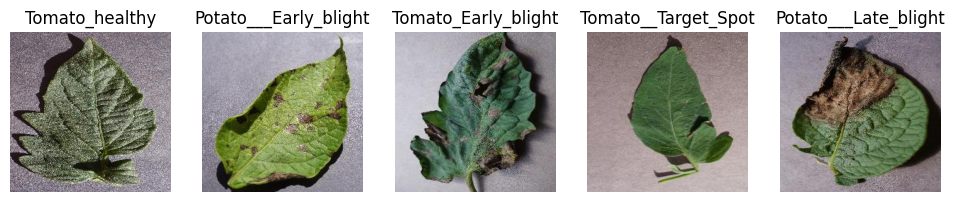

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

plt.figure(figsize=(12,6))

for i, cls in enumerate(classes[:5]):
    img_path = os.path.join(data_dir, cls, random.choice(os.listdir(os.path.join(data_dir, cls))))
    img = Image.open(img_path)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

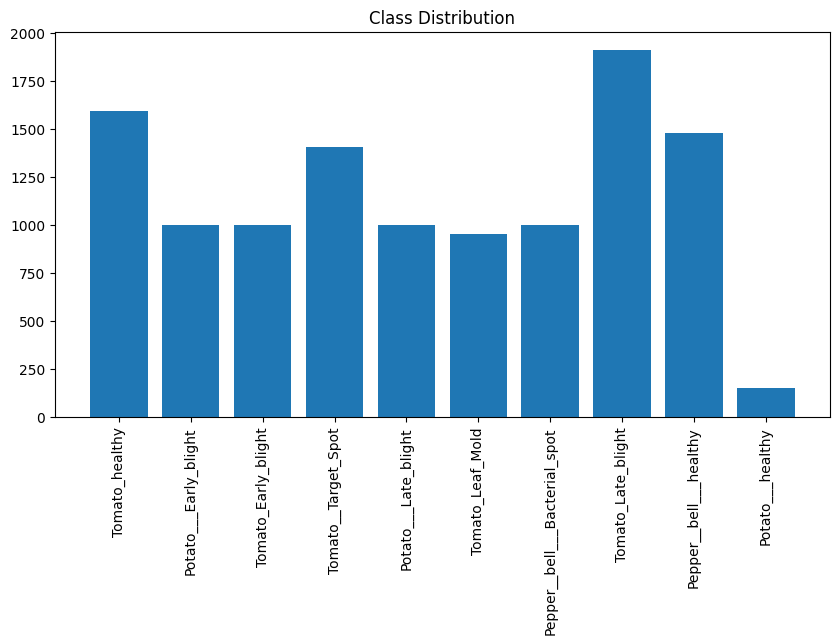

In [3]:
counts = [len(os.listdir(os.path.join(data_dir, cls))) for cls in classes]

plt.figure(figsize=(10,5))
plt.bar(classes, counts)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 9190 images belonging to 10 classes.
Found 2293 images belonging to 10 classes.


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')  # 10 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 45s 150ms/step - accuracy: 0.6610 - loss: 1.1705 - val_accuracy: 0.8844 - val_loss: 0.3467
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 41s 143ms/step - accuracy: 0.8213 - loss: 0.5873 - val_accuracy: 0.9023 - val_loss: 0.2976
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 42s 144ms/step - accuracy: 0.8600 - loss: 0.4281 - val_accuracy: 0.9023 - val_loss: 0.3022
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 43s 148ms/step - accuracy: 0.8836 - loss: 0.3683 - val_accuracy: 0.9062 - val_loss: 0.2679
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 42s 147ms/step - accuracy: 0.8968 - loss: 0.3190 - val_accuracy: 0.9128 - val_loss: 0.2569
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 42s 147ms/step - accuracy: 0.8965 - loss: 0.3159 - val_accuracy: 0.9093 - val_loss: 0.2655
Epoch 7/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 42s 146ms/step - accuracy: 0.9055 - loss: 0.2897 - val_accuracy: 0.9272 - val_loss: 0.2130
Epoch 8/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 42s 147ms/step - accuracy: 0.9088 - loss: 0

In [9]:
import numpy as np

val_data.reset()

preds = model.predict(val_data)
pred_classes = np.argmax(preds, axis=1)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step


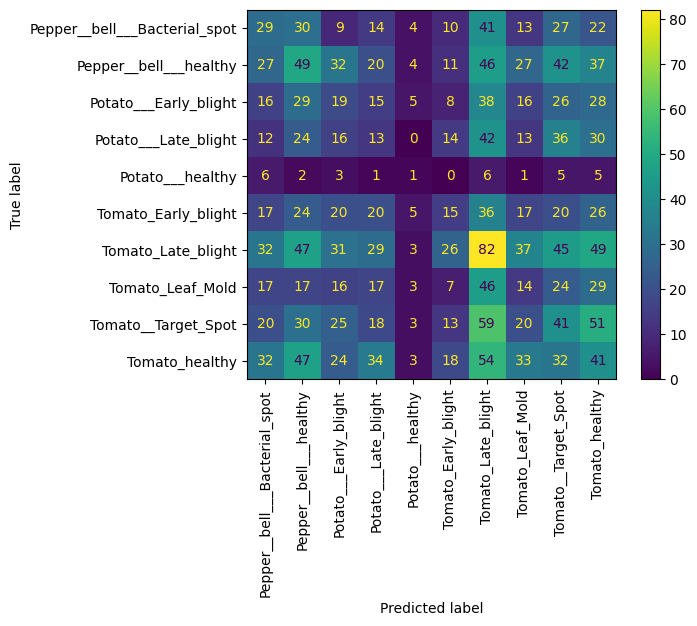

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation=90)
plt.show()

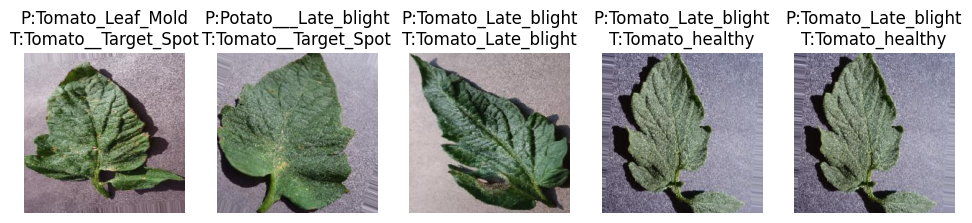

In [ ]:
import random
import matplotlib.pyplot as plt


images, labels = next(val_data)

plt.figure(figsize=(12,6))

for i in range(5):
    idx = random.randint(0, len(images)-1)
    plt.subplot(1,5,i+1)
    plt.imshow(images[idx])
    pred = class_labels[pred_classes[idx]]
    true = class_labels[np.argmax(labels[idx])]
    plt.title(f"P:{pred}\nT:{true}")
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


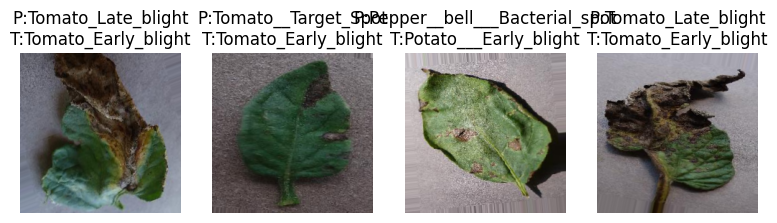

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Get one batch
images, labels = next(val_data)

# Get predictions for this batch
preds_batch = model.predict(images)
pred_classes_batch = np.argmax(preds_batch, axis=1)
true_classes_batch = np.argmax(labels, axis=1)

# Find wrong predictions in this batch
wrong = np.where(pred_classes_batch != true_classes_batch)[0]

plt.figure(figsize=(12,6))

for i in range(min(5, len(wrong))):
    idx = wrong[i]
    plt.subplot(1,5,i+1)
    plt.imshow(images[idx])
    
    pred = class_labels[pred_classes_batch[idx]]
    true = class_labels[true_classes_batch[idx]]
    
    plt.title(f"P:{pred}\nT:{true}")
    plt.axis('off')

plt.show()

In [ ]:
model.save("model.keras")